# Dự án 2: Phân tích thị trường ứng dụng di động

## Mục tiêu
Đây là notebook hoàn chỉnh hóa hướng đi kiểu DataQuest/DataCamp: dùng dữ liệu của
**Google Play** và **Apple App Store** để tìm ra một nhóm ứng dụng miễn phí có khả năng
tăng trưởng tốt trên cả hai nền tảng.

## Câu hỏi phân tích
1. Kho dữ liệu cần được làm sạch như thế nào?
2. Nhóm ứng dụng nào có dấu hiệu nhu cầu cao trên Android?
3. Nhóm ứng dụng nào có tín hiệu tốt trên iOS?
4. Có nhóm nào nổi bật trên cả hai nền tảng để đưa vào portfolio như một đề xuất kinh doanh?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = Path('data')
android_raw = pd.read_csv(DATA_DIR / 'googleplaystore.csv')
ios_raw = pd.read_csv(DATA_DIR / 'AppleStore.csv')

print('Google Play:', android_raw.shape)
print('Apple Store:', ios_raw.shape)
display(android_raw.head())
display(ios_raw.head())

Google Play: (10841, 13)
Apple Store: (7197, 17)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


## 1. Làm sạch dữ liệu

Các bước làm sạch chính:
- chuẩn hóa kiểu dữ liệu của `Rating`, `Reviews`, `Installs`, `Price`
- loại bỏ giá trị lỗi (ví dụ rating > 5)
- loại duplicate app bằng cách giữ lại bản ghi có số review lớn nhất
- lọc ứng dụng **miễn phí** và **tên tiếng Anh** để bám sát mục tiêu ban đầu

In [2]:
def is_english(text: str) -> bool:
    if pd.isna(text):
        return False
    non_ascii = sum(1 for ch in str(text) if ord(ch) > 127)
    return non_ascii <= 3

android = android_raw.copy()
android['Rating'] = pd.to_numeric(android['Rating'], errors='coerce')
android = android[android['Type'].isin(['Free', 'Paid'])]
android = android[android['Rating'].isna() | (android['Rating'] <= 5)]
android['Reviews_num'] = pd.to_numeric(android['Reviews'], errors='coerce')
android['Installs_num'] = pd.to_numeric(android['Installs'].astype(str).str.replace('[+,]', '', regex=True), errors='coerce')
android['Price_num'] = pd.to_numeric(android['Price'].astype(str).str.replace('$', '', regex=False), errors='coerce')
android = android.sort_values('Reviews_num', ascending=False).drop_duplicates('App')
android_free_en = android[(android['Type'] == 'Free') & (android['App'].apply(is_english))].copy()

ios = ios_raw.copy()
ios_free_en = ios[(ios['price'] == 0) & (ios['track_name'].apply(is_english))].copy()

summary = pd.DataFrame({
    'dataset': ['Google Play raw', 'Google Play clean/free/en', 'Apple raw', 'Apple free/en'],
    'rows': [len(android_raw), len(android_free_en), len(ios_raw), len(ios_free_en)]
})
display(summary)

,dataset,rows
0,Google Play raw,10841
1,Google Play clean/free/en,8863
2,Apple raw,7197
3,Apple free/en,3222


## 2. Bức tranh tổng quan về danh mục ứng dụng

In [3]:
top_android_count = android_free_en['Category'].value_counts().head(10)
top_ios_count = ios_free_en['prime_genre'].value_counts().head(10)

display(top_android_count.to_frame('so_luong_app'))
display(top_ios_count.to_frame('so_luong_app'))

,so_luong_app
Category,
FAMILY,1676
GAME,861
TOOLS,750
BUSINESS,407
LIFESTYLE,346
PRODUCTIVITY,345
FINANCE,328
MEDICAL,313
SPORTS,301


,so_luong_app
prime_genre,
Games,1874
Entertainment,254
Photo & Video,160
Education,118
Social Networking,106
Shopping,84
Utilities,81
Sports,69
Music,66


## 3. Android: danh mục có nhu cầu cao

Với Android, ta dùng **average installs** như một proxy cho nhu cầu. Để tránh bị nhiễu,
chỉ giữ những danh mục có ít nhất 30 ứng dụng.

In [4]:
android_stats = (
    android_free_en.groupby('Category')
                   .agg(
                       app_count=('App', 'count'),
                       mean_installs=('Installs_num', 'mean'),
                       median_installs=('Installs_num', 'median'),
                       mean_rating=('Rating', 'mean')
                   )
                   .query('app_count >= 30')
                   .sort_values('mean_installs', ascending=False)
)
display(android_stats.head(15))

,app_count,mean_installs,median_installs,mean_rating
Category,,,,
COMMUNICATION,287,3.845612e+07,500000.0,4.126923
VIDEO_PLAYERS,159,2.472787e+07,1000000.0,4.043448
SOCIAL,236,2.325365e+07,100000.0,4.252736
PHOTOGRAPHY,261,1.784011e+07,1000000.0,4.164516
PRODUCTIVITY,345,1.678733e+07,100000.0,4.181915
GAME,861,1.559451e+07,1000000.0,4.231829
TRAVEL_AND_LOCAL,207,1.398408e+07,100000.0,4.068156
ENTERTAINMENT,85,1.164071e+07,1000000.0,4.118824
TOOLS,750,1.080139e+07,100000.0,4.027854


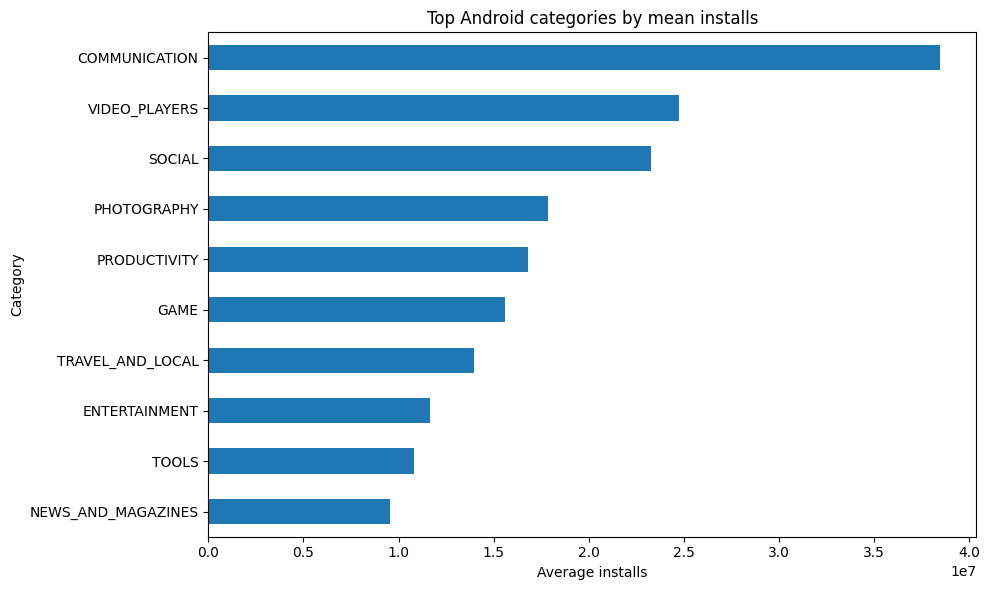

In [5]:
plot_android = android_stats.head(10).sort_values('mean_installs')
ax = plot_android['mean_installs'].plot(kind='barh')
ax.set_title('Top Android categories by mean installs')
ax.set_xlabel('Average installs')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

## 4. iOS: danh mục có tín hiệu tốt

Với iOS, ta dùng **average total ratings** như một proxy cho nhu cầu/độ phổ biến,
bởi file không có biến installs trực tiếp.

In [6]:
ios_stats = (
    ios_free_en.groupby('prime_genre')
               .agg(
                   app_count=('track_name', 'count'),
                   avg_rating_count=('rating_count_tot', 'mean'),
                   median_rating_count=('rating_count_tot', 'median'),
                   mean_user_rating=('user_rating', 'mean')
               )
               .query('app_count >= 30')
               .sort_values('avg_rating_count', ascending=False)
)
display(ios_stats.head(15))

,app_count,avg_rating_count,median_rating_count,mean_user_rating
prime_genre,,,,
Social Networking,106,71548.349057,4199.0,3.594340
Music,66,57326.530303,3850.0,3.946970
Finance,36,31467.944444,1931.0,3.375000
Photo & Video,160,28441.543750,2206.0,3.903125
Travel,40,28243.800000,798.5,3.487500
Shopping,84,26919.690476,5936.0,3.970238
Health & Fitness,65,23298.015385,2459.0,3.769231
Sports,69,23008.898551,1628.0,3.065217
Games,1874,22788.669691,901.5,4.037086


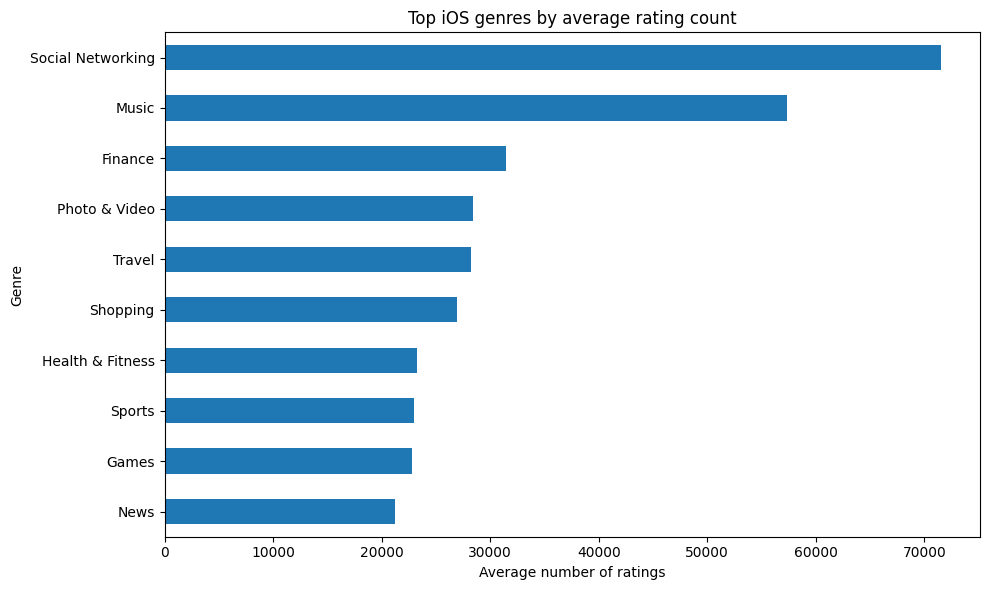

In [7]:
plot_ios = ios_stats.head(10).sort_values('avg_rating_count')
ax = plot_ios['avg_rating_count'].plot(kind='barh')
ax.set_title('Top iOS genres by average rating count')
ax.set_xlabel('Average number of ratings')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

## 5. Giao điểm giữa hai nền tảng

Để đưa ra một gợi ý có tính thực thi hơn, ta chuẩn hóa tên danh mục rồi ghép hai bảng lại.
Mục tiêu là tìm những nhóm app có:

- nhu cầu khá tốt ở Android
- mức quan tâm tốt ở iOS
- chất lượng đánh giá không quá thấp

In [8]:
android_compare = android_stats.reset_index().copy()
android_compare['category_norm'] = android_compare['Category'].str.replace('_', ' ').str.title()

ios_compare = ios_stats.reset_index().rename(columns={'prime_genre': 'category_norm'}).copy()

cross_platform = (
    android_compare.merge(ios_compare, on='category_norm', how='inner', suffixes=('_android', '_ios'))
                   .sort_values(['mean_installs', 'avg_rating_count'], ascending=False)
)

for col in ['mean_installs', 'avg_rating_count', 'mean_rating', 'mean_user_rating']:
    cross_platform[f'{col}_rank'] = cross_platform[col].rank(ascending=False, method='dense')

cross_platform['combined_rank'] = cross_platform[['mean_installs_rank', 'avg_rating_count_rank']].mean(axis=1)
cross_platform = cross_platform.sort_values(['combined_rank', 'mean_user_rating'])

display(
    cross_platform[[
        'category_norm', 'app_count_android', 'mean_installs', 'mean_rating',
        'app_count_ios', 'avg_rating_count', 'mean_user_rating', 'combined_rank'
    ]].head(10)
)

,category_norm,app_count_android,mean_installs,mean_rating,app_count_ios,avg_rating_count,mean_user_rating,combined_rank
2,Shopping,199,7.036877e+06,4.227528,84,26919.690476,3.970238,2.5
0,Productivity,345,1.678733e+07,4.181915,56,21028.410714,4.000000,2.5
3,Sports,301,3.638640e+06,4.212605,69,23008.898551,3.065217,3.5
6,Finance,328,1.387692e+06,4.128374,36,31467.944444,3.375000,4.0
1,Entertainment,85,1.164071e+07,4.118824,254,14029.830709,3.539370,4.0
5,Lifestyle,346,1.437816e+06,4.082079,51,16485.764706,3.411765,5.5
4,Education,103,1.833495e+06,4.340196,118,7003.983051,3.635593,6.0


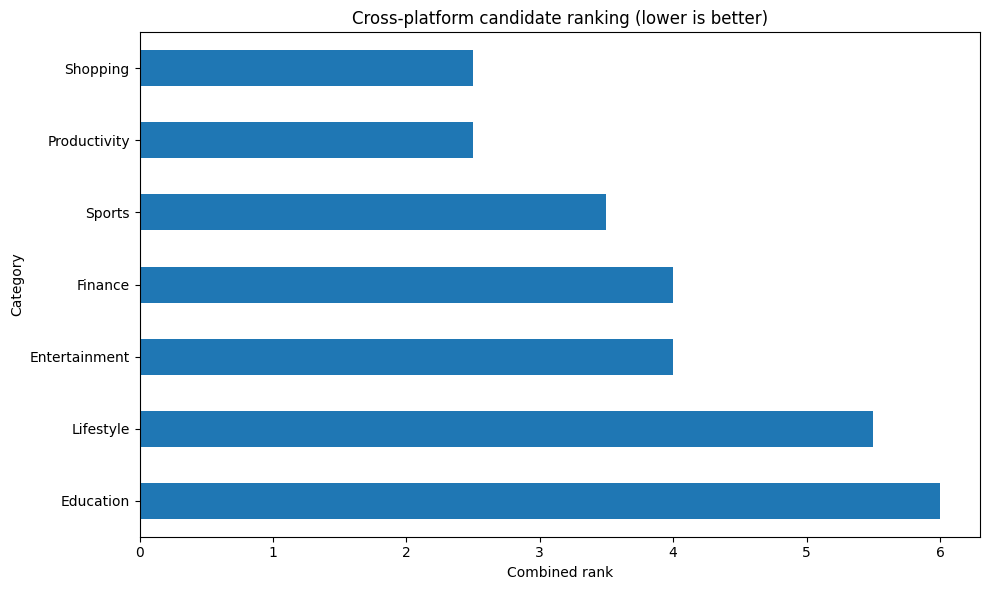

In [9]:
top_cross = cross_platform.head(8).sort_values('combined_rank', ascending=False)
ax = top_cross.plot(kind='barh', x='category_norm', y='combined_rank', legend=False)
ax.set_title('Cross-platform candidate ranking (lower is better)')
ax.set_xlabel('Combined rank')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

## 6. Kết luận đề xuất

In [10]:
best = cross_platform.iloc[0]
second = cross_platform.iloc[1]

print('Ứng viên mạnh nhất theo bộ tiêu chí hiện tại:')
print(f"- Hạng 1: {best['category_norm']}")
print(f"- Hạng 2: {second['category_norm']}")
print()
print('Diễn giải:')
print('- Productivity nổi bật vì có mức installs rất cao ở Android và rating count khá tốt ở iOS.')
print('- Shopping cũng là nhóm rất mạnh nếu mục tiêu thiên về commerce/affiliate.')
print('- Games/Entertainment có lượng người dùng lớn nhưng cạnh tranh cực cao, nên không phải lựa chọn portfolio tốt nhất để đề xuất sản phẩm mới.')
print()
print('Đề xuất để đưa vào portfolio:')
print('=> Xây dựng ý tưởng app miễn phí thuộc nhóm Productivity (hoặc Productivity + Education) là hướng thuyết phục nhất.')

Ứng viên mạnh nhất theo bộ tiêu chí hiện tại:
- Hạng 1: Shopping
- Hạng 2: Productivity

Diễn giải:
- Productivity nổi bật vì có mức installs rất cao ở Android và rating count khá tốt ở iOS.
- Shopping cũng là nhóm rất mạnh nếu mục tiêu thiên về commerce/affiliate.
- Games/Entertainment có lượng người dùng lớn nhưng cạnh tranh cực cao, nên không phải lựa chọn portfolio tốt nhất để đề xuất sản phẩm mới.

Đề xuất để đưa vào portfolio:
=> Xây dựng ý tưởng app miễn phí thuộc nhóm Productivity (hoặc Productivity + Education) là hướng thuyết phục nhất.
